In [ ]:
'''
https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

저장된 winequality-white.csv 파일을 읽어
whitewine의 등급(quality)을 분류하는 모델을 구현하기

혼동행렬,정확도,정밀도, 재현율를 출력하기

winequality-white.csv의 컬럼 정보

1 - fixed acidity : 주석산농도
2 - volatile acidity : 아세트산농도
3 - citric acid : 구연산농도
4 - residual sugar : 잔류당분농도
5 - chlorides : 염화나트륨농도
6 - free sulfur dioxide : 유리 아황산 농도
7 - total sulfur dioxide : 총 아황산 농도
8 - density : 밀도
9 - pH : ph
10 - sulphates : 황산칼륨 농도
11 - alcohol : 알코올 도수
12 - quality (score between 0 and 10) : 와인등급
'''


In [1]:
import pandas as pd

url="https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
#savefile="winequality-white.csv"
#from urllib.request import urlretrieve
#urlretrieve(url, savefile)

#winequality-white.csv 파일을 읽어서 df 변수에 저장하기
df = pd.read_csv(url, sep=";")
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [2]:

# 등급별 갯수 출력하기
df["quality"].value_counts()
count_data = df.groupby('quality')["quality"].count()
count_data


quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: quality, dtype: int64

<Axes: xlabel='quality'>

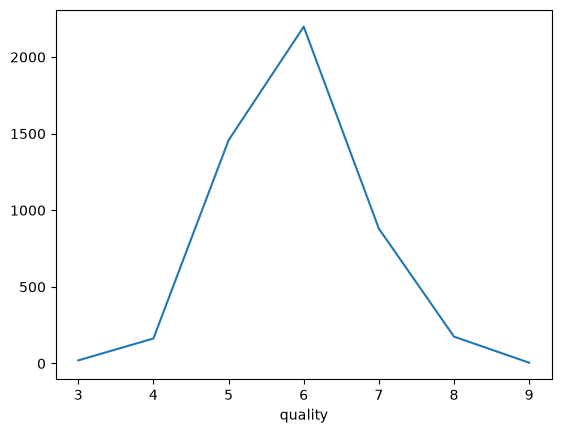

In [4]:

#선그래프로 출력하기
count_data.plot()


In [5]:
# 독립변수, 종속변수 분리.
x = df.drop("quality",axis=1)  #독립변수
y = df["quality"]              #종속변수

In [6]:

# 학습데이터, 검증데이터 분리.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test =train_test_split(x, y, test_size=0.2,random_state=10)

In [7]:

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=0)
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(y_pred[:10])
y_test[:10].values

[6 6 5 6 6 6 5 6 5 6]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([6, 5, 5, 5, 6, 6, 6, 6, 6, 6])

In [8]:

#혼동행렬
from sklearn.metrics import confusion_matrix
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[  0   0   1   1   0   0   0]
 [  0   0  10  19   0   0   0]
 [  0   0 104 176   0   0   0]
 [  0   0  94 356   0   0   0]
 [  0   0  12 167   1   0   0]
 [  0   0   5  33   0   0   0]
 [  0   0   1   0   0   0   0]]


In [10]:

'''
  정밀도,재현율,f1-score는 기본적으로 2진 분류 에서 사용됨
  다중분류는 속성값으로  average='macro' 속성값 필요
'''
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score
print("정확도(accuracy):",accuracy_score(y_test.values, y_pred))
print("정밀도(Precision) : ", precision_score(y_test.values, y_pred,average='macro'))
print("재현율(Recall) : ",recall_score(y_test, y_pred,average='macro'))
print("F1-score : ",f1_score(y_test, y_pred,average='macro'))

정확도(accuracy): 0.4704081632653061
정밀도(Precision) :  0.27593629072211884
재현율(Recall) :  0.16687074829931972
F1-score :  0.144807460551938


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [11]:

#의사결정나무 모델을 기본으로 한 분류 알고리즘 
#성능 : 좋다.
#단점 : 시간이 오래 걸림.
from sklearn.ensemble import GradientBoostingClassifier
#학습하기
clf= GradientBoostingClassifier()
clf.fit(x_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [12]:

#예측하기
y_pred = clf.predict(x_test)
print(y_pred[:10])
print(y_test[:10].values)


[6 5 4 5 6 6 6 6 5 6]
[6 5 5 5 6 6 6 6 6 6]


In [13]:

#혼동 행렬 출력하기.
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

[[  0   1   0   0   1   0   0]
 [  0   2  18   9   0   0   0]
 [  0   6 159 109   5   1   0]
 [  1   6  73 337  33   0   0]
 [  0   0   6 104  68   2   0]
 [  0   0   0  19   8  10   1]
 [  0   0   0   1   0   0   0]]


In [14]:
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score
print("정확도(accuracy):",accuracy_score(y_test.values, y_pred))
print("정밀도(Precision) : ", precision_score(y_test.values, y_pred,average='macro'))
print("재현율(Recall) : ",recall_score(y_test, y_pred,average='macro'))
print("F1-score : ",f1_score(y_test, y_pred,average='macro'))

정확도(accuracy): 0.5877551020408164
정밀도(Precision) :  0.3852857424194226
재현율(Recall) :  0.2895210316431473
F1-score :  0.31319590628325367


In [15]:

print(accuracy_score(y_test, y_pred))

'''
 y : 3 ~ 9 등급 => 3개등급으로 줄이기
  4이하 : 0,  7이하 : 1,  그외  : 2
''' 
y.value_counts()
y=df["quality"]
newlist = []
for v in list(y) :
    if v <= 4 :
        newlist += [0]
    elif v <= 7 :    
        newlist += [1]
    else :    
        newlist += [2]
y = newlist
y[:10]
x_train, x_test, y_train, y_test =\
    train_test_split(x, y, test_size=0.2,random_state=10)
    
clf= GradientBoostingClassifier()
clf.fit(x_train,y_train)

#예측하기
y_pred = clf.predict(x_test)
#정확도 출력하기.
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print(confmat)

print(accuracy_score(y_test, y_pred))


0.5877551020408164
[[  3  28   0]
 [  8 899   3]
 [  0  30   9]]
0.9295918367346939


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font', family ='AppleGothic')
seoul1 = pd.read_csv("seoul_0719.csv", encoding="cp949")
seoul2 = pd.read_csv("seoul_1926.csv", encoding="cp949")
seoul1.info()
seoul2.info()
del seoul1['지점'] #0719 데이터 중 지점 컬럼을 삭제
seoul2 = seoul2.drop(['지점','지점명'], axis=1) #1926 데이터에서 지점, 지점명 컬럼 삭제
seoul1.info()
seoul2.info()

<class 'pandas.DataFrame'>
RangeIndex: 40221 entries, 0 to 40220
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   날짜       40221 non-null  str    
 1   지점       40221 non-null  int64  
 2   평균기온(℃)  39465 non-null  float64
 3   최저기온(℃)  39464 non-null  float64
 4   최고기온(℃)  39463 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 1.5 MB
<class 'pandas.DataFrame'>
RangeIndex: 2820 entries, 0 to 2819
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   지점        2820 non-null   int64  
 1   지점명       2820 non-null   str    
 2   일시        2820 non-null   str    
 3   평균기온(°C)  2820 non-null   float64
 4   최저기온(°C)  2819 non-null   float64
 5   최고기온(°C)  2820 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 132.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 40221 entries, 0 to 40220
Data columns (total 4 columns):
 #   Column   N

In [28]:
cols = ['날짜','평균기온','최저기온','최고기온']  #컬럼값 일치
seoul1.columns = cols
seoul2.columns = cols
seoul = pd.concat([seoul1,seoul2],axis=0)  #행 기준으로 붙이기
seoul.info()

<class 'pandas.DataFrame'>
Index: 43041 entries, 0 to 2819
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   날짜      43041 non-null  str    
 1   평균기온    42285 non-null  float64
 2   최저기온    42283 non-null  float64
 3   최고기온    42283 non-null  float64
dtypes: float64(3), str(1)
memory usage: 1.6 MB


In [29]:
seoul = seoul.drop_duplicates() #중복된 레코드 삭제

In [30]:
#년도 컬럼 추가하기. 
seoul['년도'] = seoul['날짜'].apply(lambda x: x[:4])
#seoul0922 : 09-22일 데이터만 저장
seoul0922 = seoul[seoul['날짜'].apply(lambda x: x[5:])=='09-22']
seoul0922 = seoul0922.dropna(subset=["평균기온","최저기온","최고기온"],axis=0)  #결측값 제거
seoul0922.head()

,날짜,평균기온,최저기온,최고기온,년도
357,1908-09-22,15.6,10.7,21.8,1908
722,1909-09-22,21.2,16.6,26.8,1909
1087,1910-09-22,19.2,14.9,25.7,1910
1452,1911-09-22,18.9,13.0,26.0,1911
1818,1912-09-22,16.1,9.6,23.6,1912


In [32]:
from statsmodels.graphics.tsaplots import plot_predict
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(seoul0922['평균기온'].values,order=(2,1,2))
model_fit = model.fit()  #학습하기
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  114
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -233.171
Date:                Tue, 22 Sep 2026   AIC                            476.341
Time:                        17:40:30   BIC                            489.978
Sample:                             0   HQIC                           481.875
                                - 114                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6790      0.336     -2.022      0.043      -1.337      -0.021
ar.L2          0.1308      0.113      1.157      0.247      -0.091       0.353
ma.L1         -0.1970      0.342     -0.577      0.5

In [ ]:
forecast_data = model_fit.forecast(steps=5) #5일 정보를 예측
forecast_data 

array([20.41678956, 20.35281317, 20.28070781, 20.32129462, 20.28430513])

In [36]:
forecast_obj = model_fit.get_forecast(steps=5)
conf_int = forecast_obj.conf_int() # 신뢰구간 [하한값, 상한값]
pred_y = forecast_obj.predicted_mean

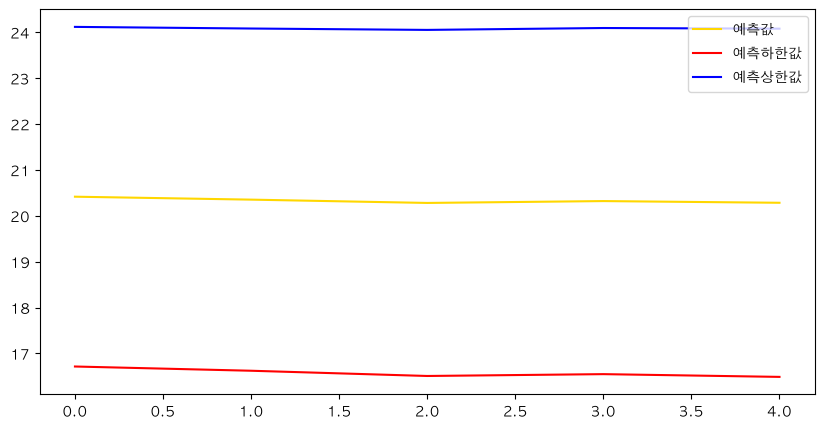

In [37]:
plt.rc('font', family='AppleGothic')
pred_y_lower = conf_int[:,0] #하한값
pred_y_upper = conf_int[:,1] #상한값
plt.figure(figsize=(10, 5))
plt.plot(pred_y, color='gold',label='예측값')
plt.plot(pred_y_lower, color='red',label='예측하한값')
plt.plot(pred_y_upper, color='blue',label='예측상한값')
plt.legend()
plt.show()